# Credit Card Customer Segmentation & Churn Risk Prediction (Group 17)

**Dataset :**  [CC GENERAL.csv](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

**Goals:**
- **Segment customers** using K-Means clustering to identify behavioral groups
- **Predict churn risk** by identifying high-risk customers based on cluster & behavioral signals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('CC GENERAL.csv')

# Dataset Overview



In [3]:
print("DF info")
df.info()
print("df.shape:", df.shape)

DF info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12

**COLUMN DESCRIPTION**

​CUST_ID: Unique identification of the credit card holder.

​BALANCE: Amount remaining in the account to make purchases.

​BALANCE_FREQUENCY: How frequently the balance is updated (score between 0 and 1).

​PURCHASES: Total amount of purchases made from the account.

​ONEOFF_PURCHASES: Maximum purchase amount done in one go.

​INSTALLMENTS_PURCHASES: Amount of purchase done in installments.

​CASH_ADVANCE: Cash in advance given by the user.

​PURCHASES_FREQUENCY: How frequently the purchases are being made.

​ONEOFF_PURCHASES_FREQUENCY: How frequently purchases are happening in one go.

​PURCHASES_INSTALLMENTS_FREQUENCY: How frequently purchases in installments are being made.

​CASH_ADVANCE_FREQUENCY: How frequently the cash in advance is being paid.

​CASH_ADVANCE_TRX: Number of transactions made with "Cash in Advance".

​PURCHASES_TRX: Number of purchase transactions made.

​CREDIT_LIMIT: Limit of Credit Card for the user.

​PAYMENTS: Amount of Payment done by user.

​MINIMUM_PAYMENTS: Minimum amount of payment made by user.

​PRC_FULL_PAYMENT: Percent of full payment paid by user.

​TENURE: Tenure of credit card service for user.

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
df.head(15)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


The dataset contains 8950 observations and 18 features.
The results of df.info() reveal that CUST_ID is an object datatype that must be removed for clustering.
It is also observed that there are missing values in MINIMUM_PAYMENTS(313) and CREDIT_LIMIT(1) which require imputation before modeling.

df.describe() shows that for BALANCE, the mean is 1564.474828, but the max is 19043.138560. This wide gap suggests a need for outlier detection.

# **Missing Values Analysis**

In [6]:
#missing data count
missing_data = df.isnull().sum()
print("Features with missing data:")
print(missing_data[missing_data > 0])

Features with missing data:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


# **Exploratory Data Analysis (EDA)**

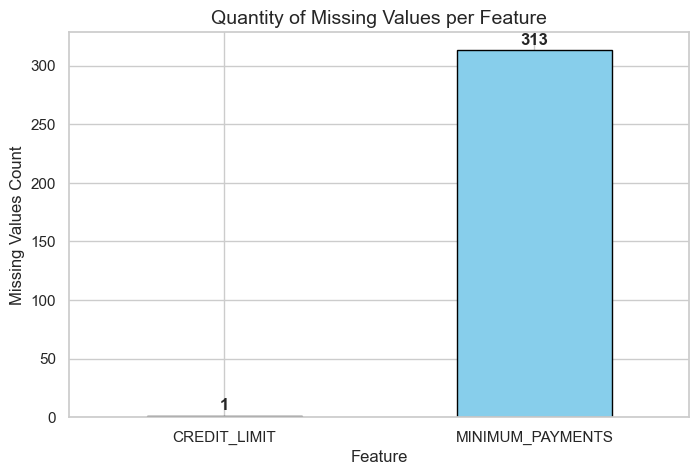

In [7]:
#visualizing using a barchart
missing= missing_data[missing_data > 0]

plt.figure(figsize=(8, 5))
missing.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Quantity of Missing Values per Feature', fontsize=14)
plt.xlabel('Feature')
plt.ylabel('Missing Values Count')
plt.xticks(rotation=0)

for i,v in enumerate(missing):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.show()

# Numerical features

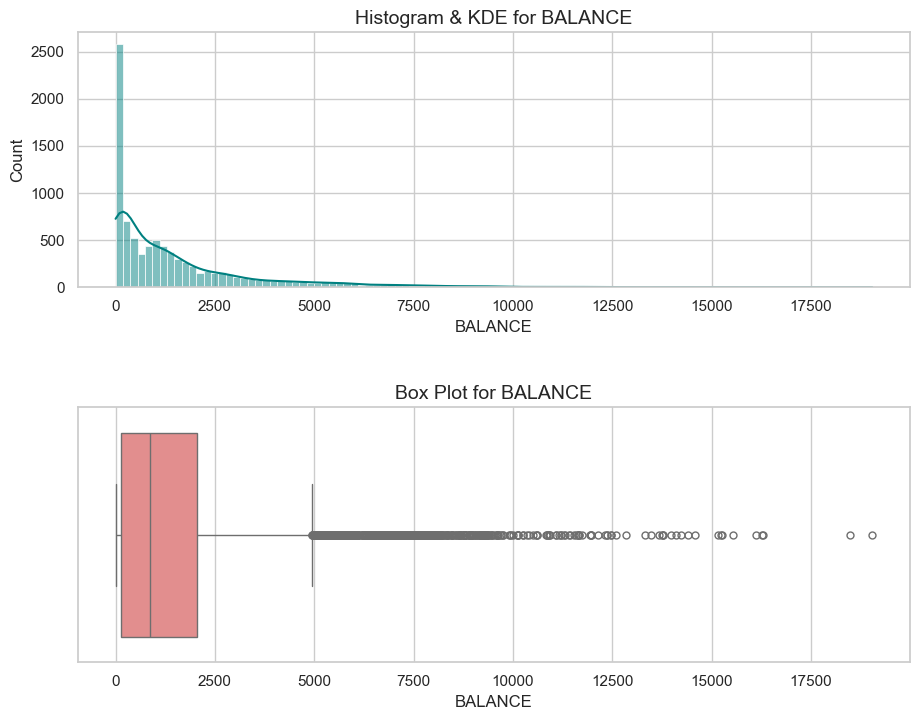

--- Statistics for BALANCE ---


,Metric,Value
0,Skewness,2.393386
1,Kurtosis,7.674751
2,Mean,1564.474828
3,Median,873.385231
4,Std Dev,2081.531879
5,Min,0.000000
6,Max,19043.138560
7,25%,128.281915
8,50%,873.385231
9,75%,2054.140036


------------------------------------------------------------


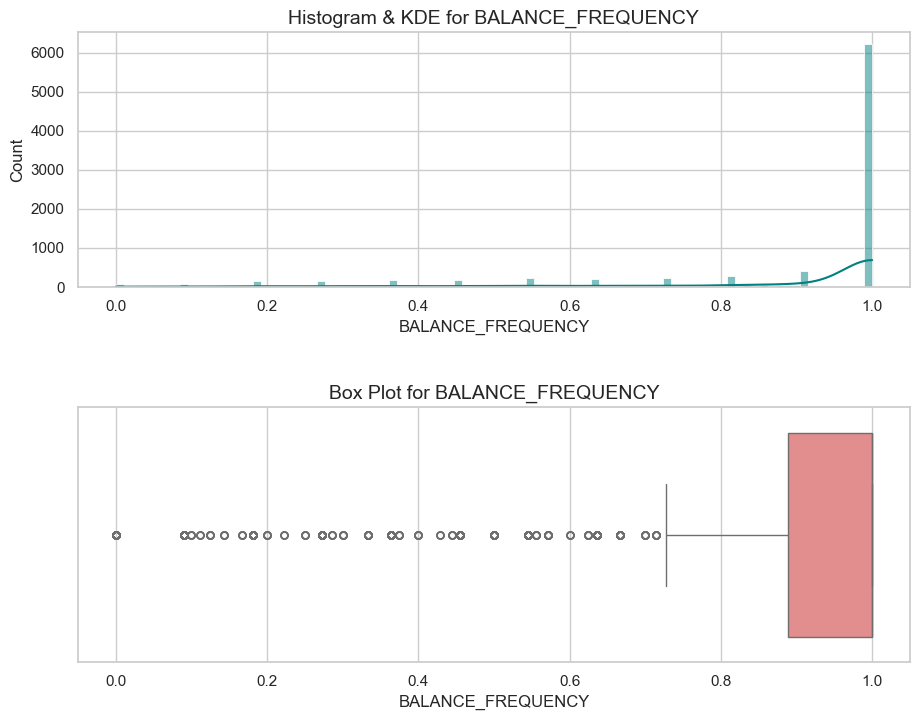

--- Statistics for BALANCE_FREQUENCY ---


,Metric,Value
0,Skewness,-2.023266
1,Kurtosis,3.092370
2,Mean,0.877271
3,Median,1.000000
4,Std Dev,0.236904
5,Min,0.000000
6,Max,1.000000
7,25%,0.888889
8,50%,1.000000
9,75%,1.000000


------------------------------------------------------------


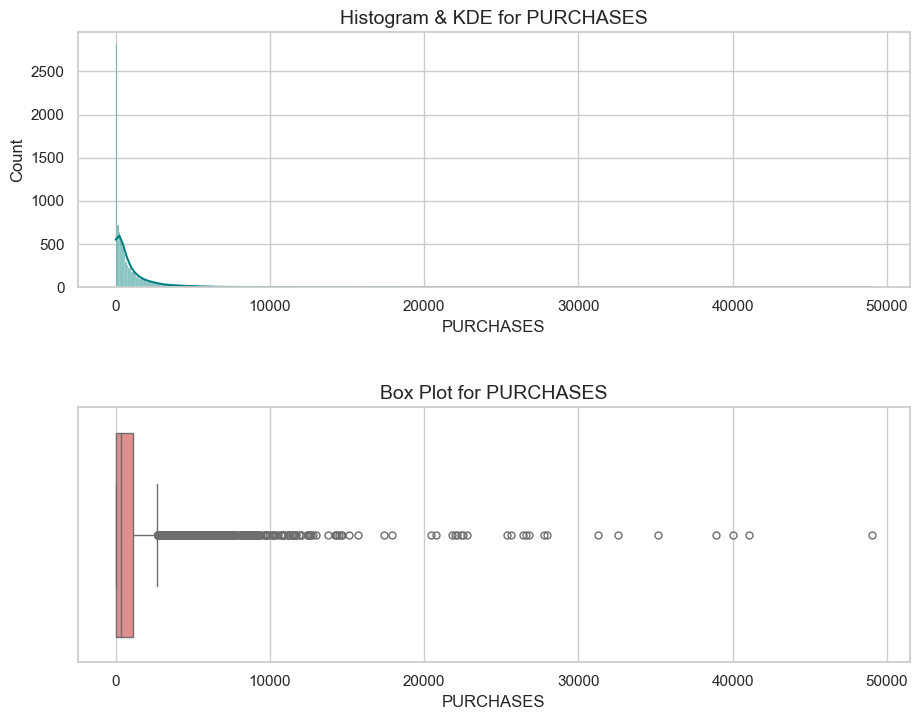

--- Statistics for PURCHASES ---


,Metric,Value
0,Skewness,8.144269
1,Kurtosis,111.388771
2,Mean,1003.204834
3,Median,361.280000
4,Std Dev,2136.634782
5,Min,0.000000
6,Max,49039.570000
7,25%,39.635000
8,50%,361.280000
9,75%,1110.130000


------------------------------------------------------------


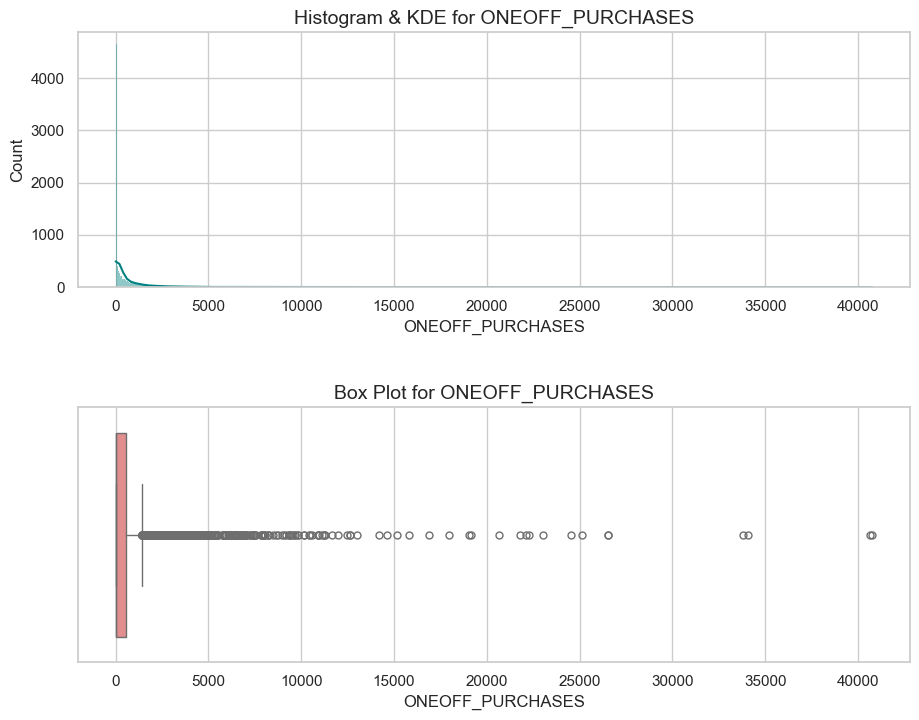

--- Statistics for ONEOFF_PURCHASES ---


,Metric,Value
0,Skewness,10.045083
1,Kurtosis,164.187572
2,Mean,592.437371
3,Median,38.000000
4,Std Dev,1659.887917
5,Min,0.000000
6,Max,40761.250000
7,25%,0.000000
8,50%,38.000000
9,75%,577.405000


------------------------------------------------------------


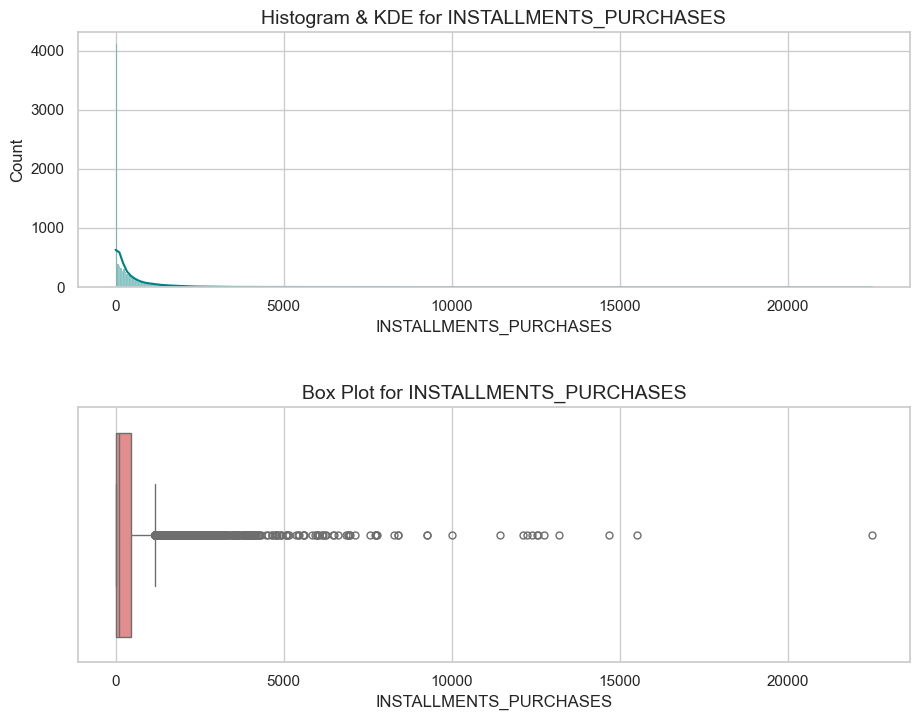

--- Statistics for INSTALLMENTS_PURCHASES ---


,Metric,Value
0,Skewness,7.299120
1,Kurtosis,96.575178
2,Mean,411.067645
3,Median,89.000000
4,Std Dev,904.338115
5,Min,0.000000
6,Max,22500.000000
7,25%,0.000000
8,50%,89.000000
9,75%,468.637500


------------------------------------------------------------


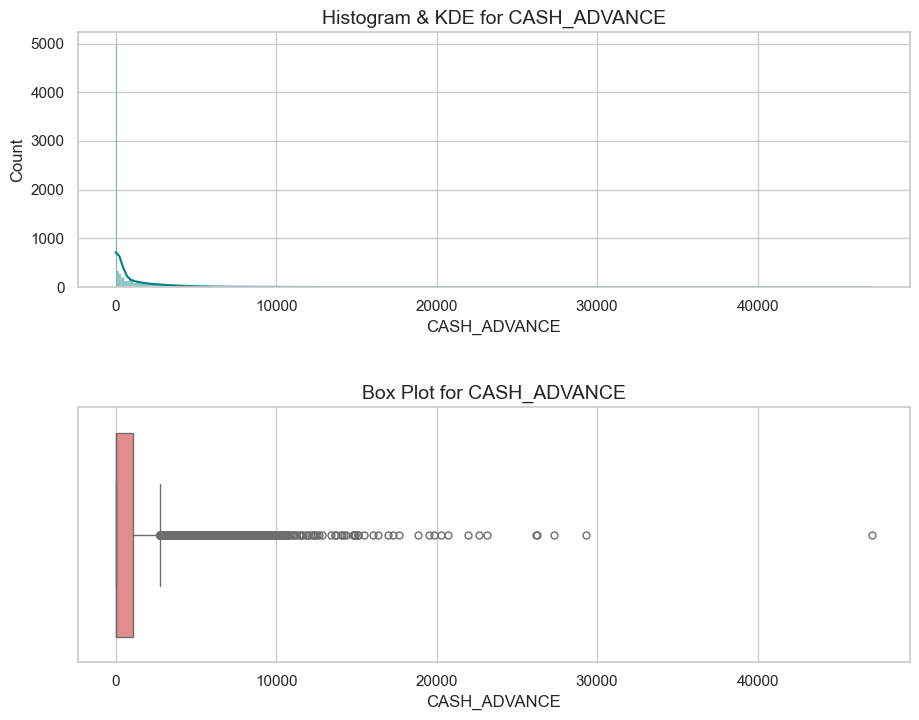

--- Statistics for CASH_ADVANCE ---


,Metric,Value
0,Skewness,5.166609
1,Kurtosis,52.899434
2,Mean,978.871112
3,Median,0.000000
4,Std Dev,2097.163877
5,Min,0.000000
6,Max,47137.211760
7,25%,0.000000
8,50%,0.000000
9,75%,1113.821139


------------------------------------------------------------


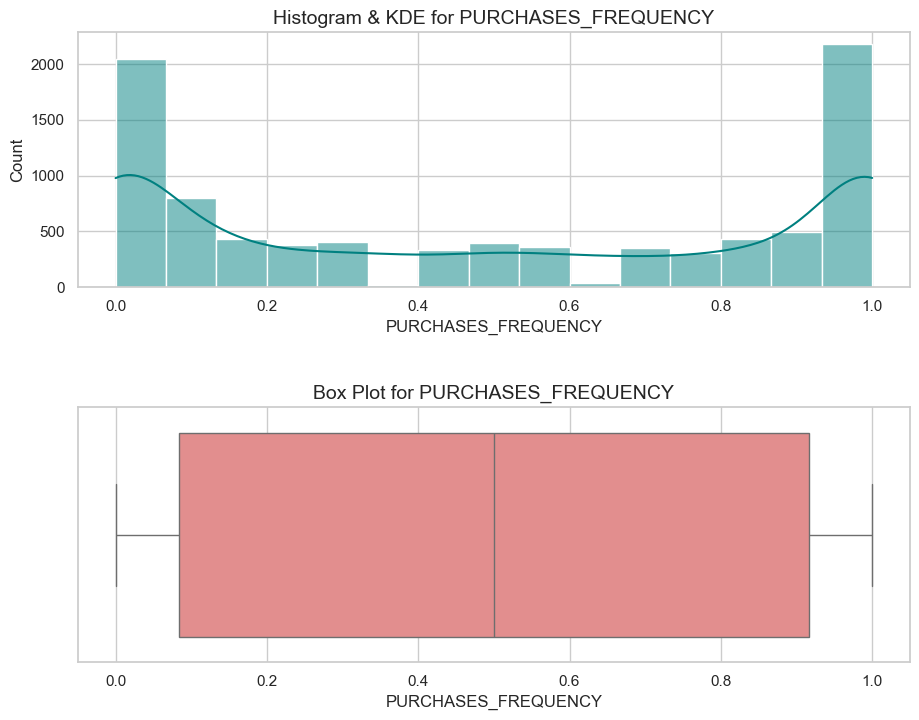

--- Statistics for PURCHASES_FREQUENCY ---


,Metric,Value
0,Skewness,0.060164
1,Kurtosis,-1.638631
2,Mean,0.490351
3,Median,0.500000
4,Std Dev,0.401371
5,Min,0.000000
6,Max,1.000000
7,25%,0.083333
8,50%,0.500000
9,75%,0.916667


------------------------------------------------------------


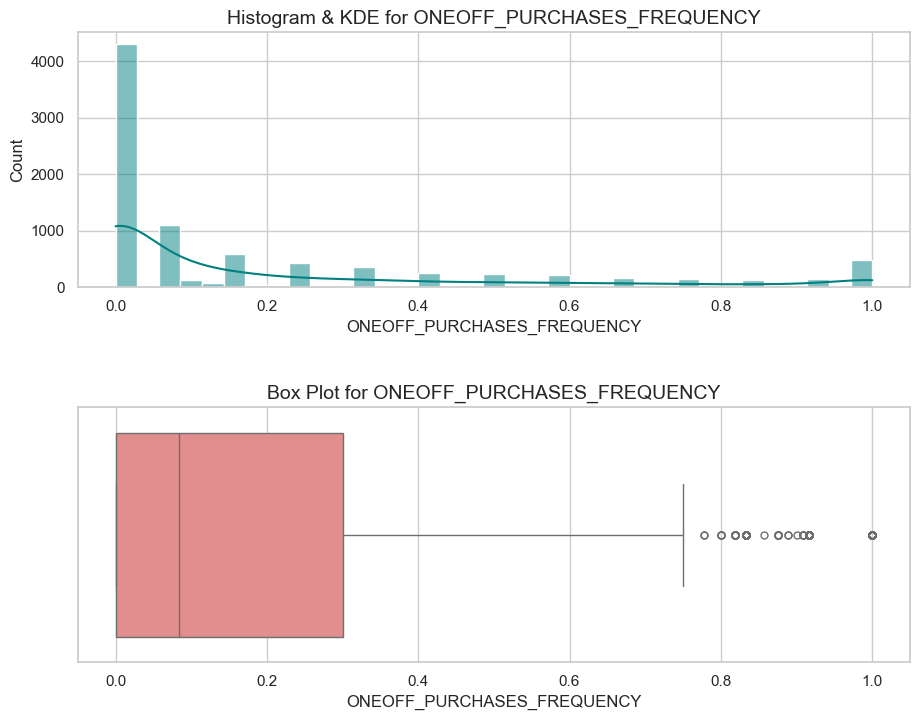

--- Statistics for ONEOFF_PURCHASES_FREQUENCY ---


,Metric,Value
0,Skewness,1.535613
1,Kurtosis,1.161846
2,Mean,0.202458
3,Median,0.083333
4,Std Dev,0.298336
5,Min,0.000000
6,Max,1.000000
7,25%,0.000000
8,50%,0.083333
9,75%,0.300000


------------------------------------------------------------


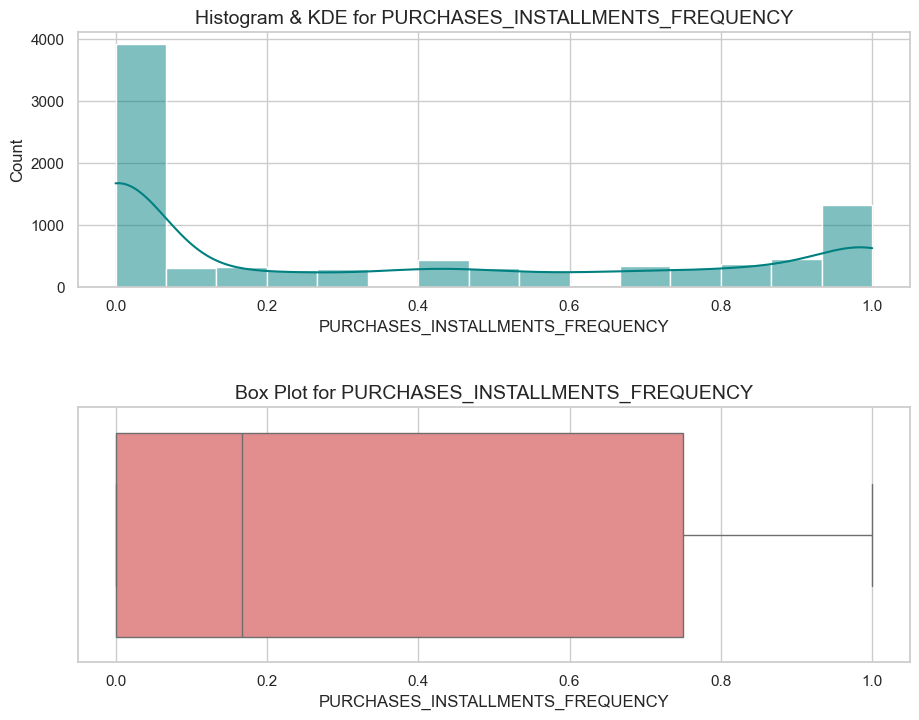

--- Statistics for PURCHASES_INSTALLMENTS_FREQUENCY ---


,Metric,Value
0,Skewness,0.509201
1,Kurtosis,-1.398632
2,Mean,0.364437
3,Median,0.166667
4,Std Dev,0.397448
5,Min,0.000000
6,Max,1.000000
7,25%,0.000000
8,50%,0.166667
9,75%,0.750000


------------------------------------------------------------


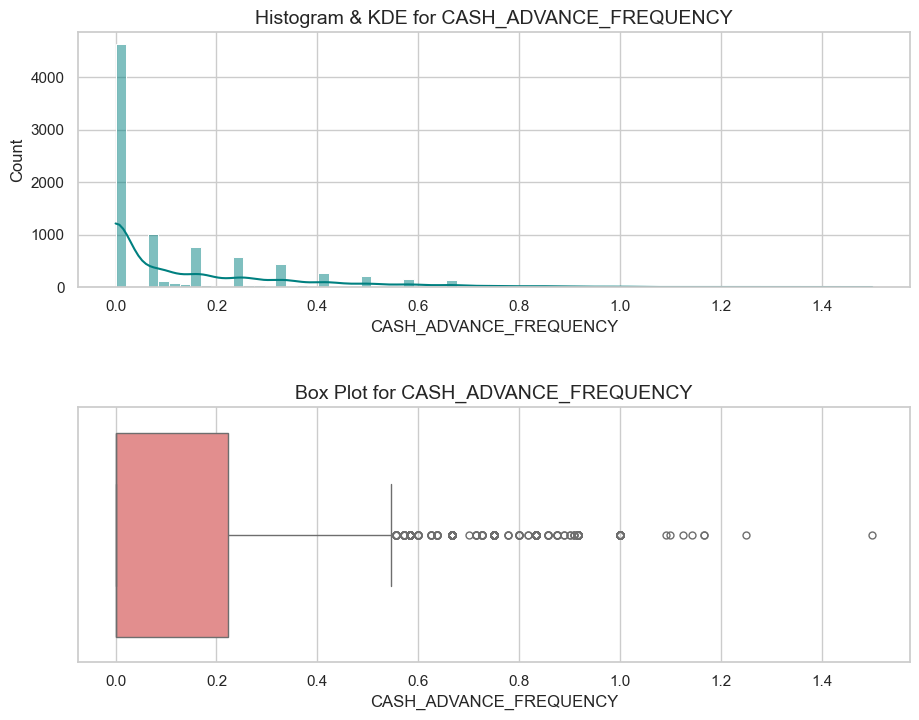

--- Statistics for CASH_ADVANCE_FREQUENCY ---


,Metric,Value
0,Skewness,1.828686
1,Kurtosis,3.334734
2,Mean,0.135144
3,Median,0.000000
4,Std Dev,0.200121
5,Min,0.000000
6,Max,1.500000
7,25%,0.000000
8,50%,0.000000
9,75%,0.222222


------------------------------------------------------------


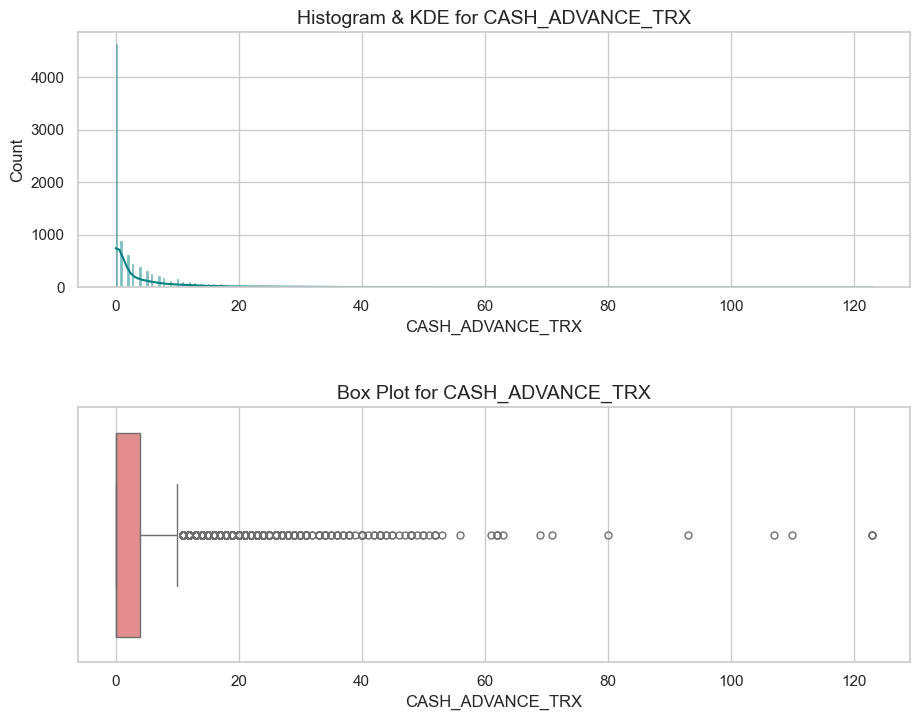

--- Statistics for CASH_ADVANCE_TRX ---


,Metric,Value
0,Skewness,5.721298
1,Kurtosis,61.646862
2,Mean,3.248827
3,Median,0.000000
4,Std Dev,6.824647
5,Min,0.000000
6,Max,123.000000
7,25%,0.000000
8,50%,0.000000
9,75%,4.000000


------------------------------------------------------------


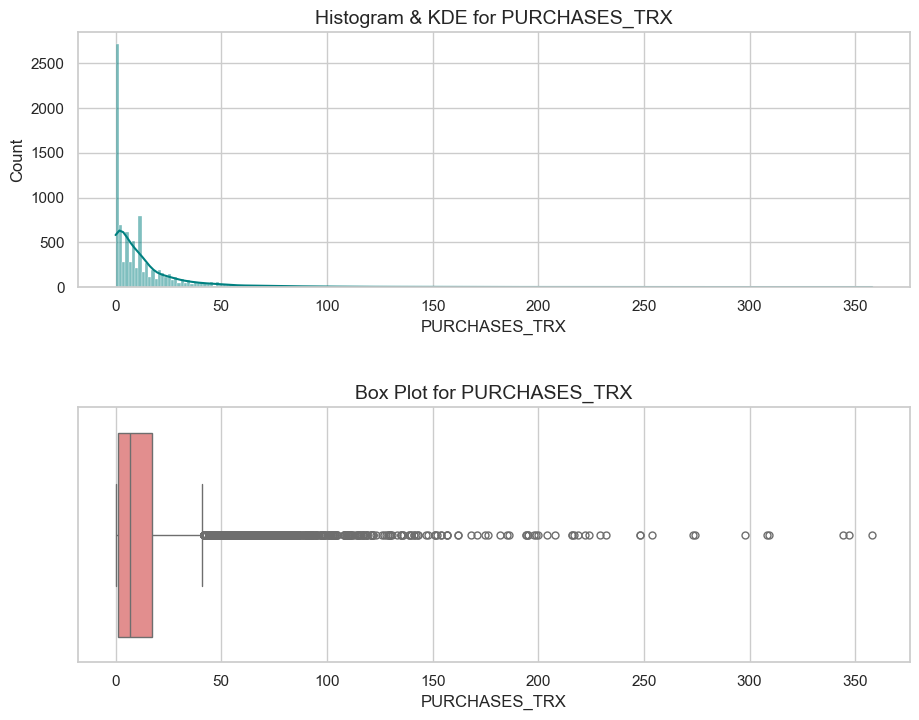

--- Statistics for PURCHASES_TRX ---


,Metric,Value
0,Skewness,4.630655
1,Kurtosis,34.793100
2,Mean,14.709832
3,Median,7.000000
4,Std Dev,24.857649
5,Min,0.000000
6,Max,358.000000
7,25%,1.000000
8,50%,7.000000
9,75%,17.000000


------------------------------------------------------------


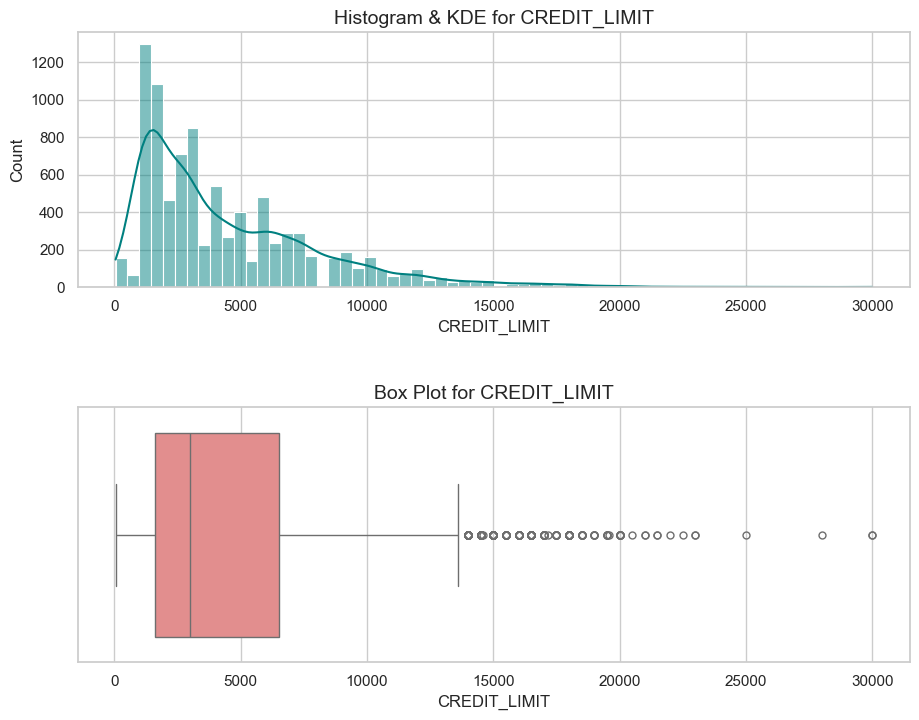

--- Statistics for CREDIT_LIMIT ---


,Metric,Value
0,Skewness,1.522464
1,Kurtosis,2.836656
2,Mean,4494.449450
3,Median,3000.000000
4,Std Dev,3638.815725
5,Min,50.000000
6,Max,30000.000000
7,25%,1600.000000
8,50%,3000.000000
9,75%,6500.000000


------------------------------------------------------------


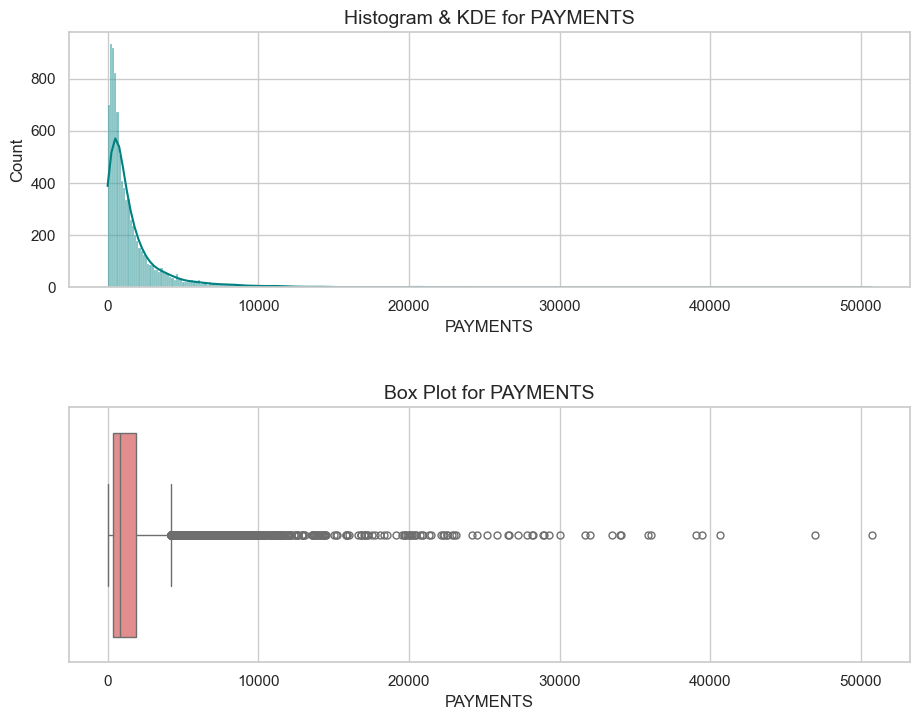

--- Statistics for PAYMENTS ---


,Metric,Value
0,Skewness,5.907620
1,Kurtosis,54.770736
2,Mean,1733.143852
3,Median,856.901546
4,Std Dev,2895.063757
5,Min,0.000000
6,Max,50721.483360
7,25%,383.276166
8,50%,856.901546
9,75%,1901.134317


------------------------------------------------------------


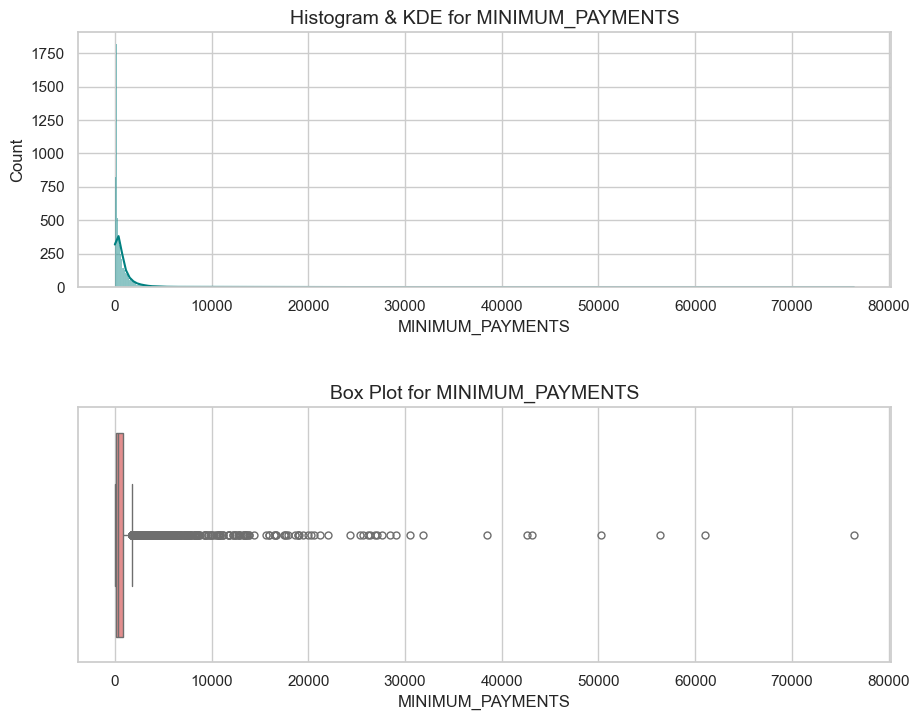

--- Statistics for MINIMUM_PAYMENTS ---


,Metric,Value
0,Skewness,13.622797
1,Kurtosis,283.989986
2,Mean,864.206542
3,Median,312.343947
4,Std Dev,2372.446607
5,Min,0.019163
6,Max,76406.207520
7,25%,169.123707
8,50%,312.343947
9,75%,825.485459


------------------------------------------------------------


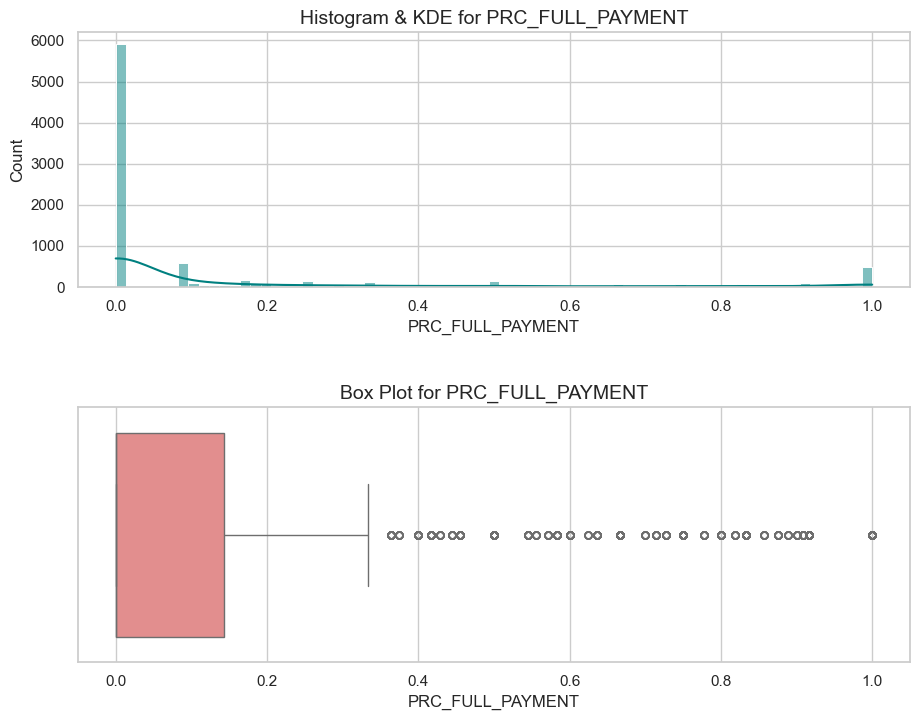

--- Statistics for PRC_FULL_PAYMENT ---


,Metric,Value
0,Skewness,1.942820
1,Kurtosis,2.432395
2,Mean,0.153715
3,Median,0.000000
4,Std Dev,0.292499
5,Min,0.000000
6,Max,1.000000
7,25%,0.000000
8,50%,0.000000
9,75%,0.142857


------------------------------------------------------------


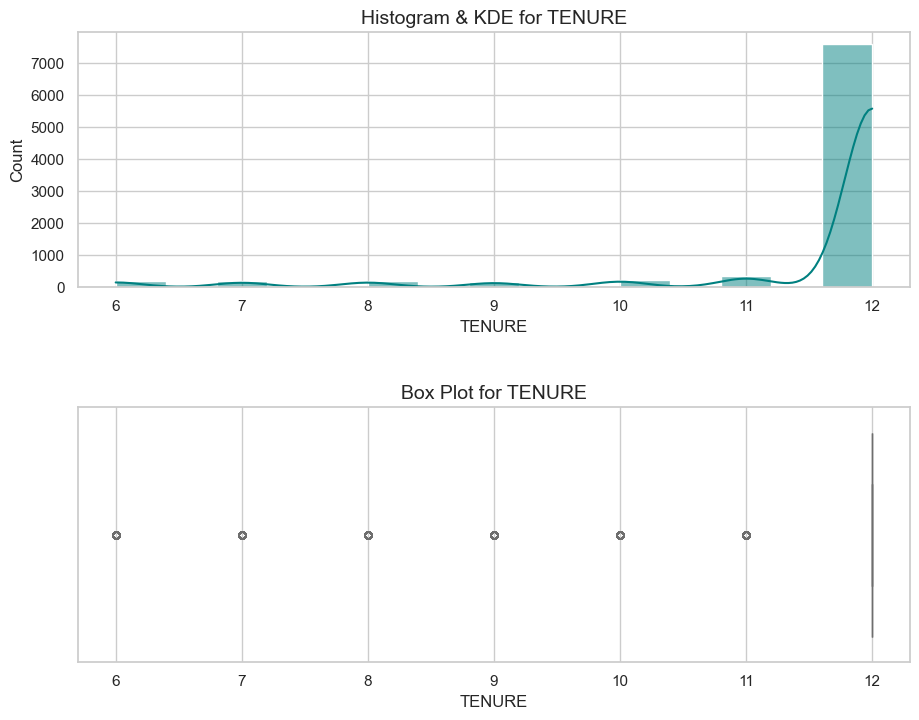

--- Statistics for TENURE ---


,Metric,Value
0,Skewness,-2.943017
1,Kurtosis,7.694823
2,Mean,11.517318
3,Median,12.000000
4,Std Dev,1.338331
5,Min,6.000000
6,Max,12.000000
7,25%,12.000000
8,50%,12.000000
9,75%,12.000000


------------------------------------------------------------


In [8]:

# Numeric columns only
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    plt.figure(figsize=(10, 8))

    # 1. Histogram
    plt.subplot(2, 1, 1)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Histogram & KDE for {col}', fontsize=14)

    # 2. Box Plot Outlier Detection
    plt.subplot(2, 1, 2)
    sns.boxplot(x=df[col], color='lightcoral', fliersize=5)
    plt.title(f'Box Plot for {col}', fontsize=14)

    plt.tight_layout(pad=3.0)
    plt.show()

    # 3. Descriptive Stats, Skewness, and Kurtosis
    stats_df = pd.DataFrame({
        'Metric': ['Skewness', 'Kurtosis', 'Mean', 'Median', 'Std Dev', 'Min', 'Max', '25%', '50%', '75%'],
        'Value': [
            df[col].skew(),
            df[col].kurt(),
            df[col].mean(),
            df[col].median(),
            df[col].std(),
            df[col].min(),
            df[col].max(),
            df[col].quantile(0.25),
            df[col].quantile(0.5),
            df[col].quantile(0.75)
        ]
    })

    print(f"--- Statistics for {col} ---")
    display(stats_df)
    print("-" * 60)

**Findings**

1. Financial variables like BALANCE, PURCHASES, and CASH_ADVANCE are highly right-skewed. This indicates that the bank's revenue is likely driven by a small percentage of high-activity users.

2. The Box Plots reveal extreme outliers in almost every column. These aren't errors but they represent high-net-worth customers who behave differently than the average cardholder.
3. The presence of high Kurtosis and Skewness across the board validates our decision to use the Median for missing value imputation and StandardScaler for feature scaling.

#**Categorical Features**

In [9]:
#Checking for features with very few unique values
unique_counts = df.nunique()
print("Unique values per feature:")
print(unique_counts)

Unique values per feature:
CUST_ID                             8950
BALANCE                             8871
BALANCE_FREQUENCY                     43
PURCHASES                           6203
ONEOFF_PURCHASES                    4014
INSTALLMENTS_PURCHASES              4452
CASH_ADVANCE                        4323
PURCHASES_FREQUENCY                   47
ONEOFF_PURCHASES_FREQUENCY            47
PURCHASES_INSTALLMENTS_FREQUENCY      47
CASH_ADVANCE_FREQUENCY                54
CASH_ADVANCE_TRX                      65
PURCHASES_TRX                        173
CREDIT_LIMIT                         205
PAYMENTS                            8711
MINIMUM_PAYMENTS                    8636
PRC_FULL_PAYMENT                      47
TENURE                                 7
dtype: int64


TENURE has only 7 unique values, making it the only feature that exhibits categorical behavior(discrete).

--- Class Distribution: TENURE ---


,Count,Percentage (%)
TENURE,,
12,7584,84.74
11,365,4.08
10,236,2.64
6,204,2.28
8,196,2.19
7,190,2.12
9,175,1.96


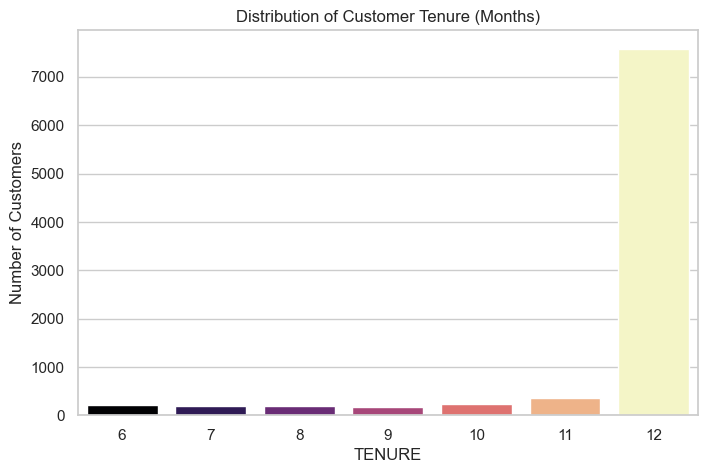

In [10]:
#Frequency table
cat_summary = pd.DataFrame({
    'Count': df['TENURE'].value_counts(),
    'Percentage (%)': (df['TENURE'].value_counts(normalize=True) * 100).round(2)
})

print("--- Class Distribution: TENURE ---")
display(cat_summary)

# Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TENURE', hue='TENURE', palette='magma', legend=False)
plt.title('Distribution of Customer Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

The majority of customers (84.7%) have a 12-month tenure. This means that, while it is a categorical class, it might not provide much separation between our clusters, since almost everyone belongs to one group. We'll look at the financial features for better segmentation.

# **UNIVARIATE ANALYSIS**


1. ​Concentrations: Some financial features exhibit Zero-Inflation (especially CASH_ADVANCE and PURCHASES_INSTALLMENTS). This means a large segment of the population does not use these specific services at all.
2. ​Ranges: The range of PURCHASES is massive **(0 to 49,036)**, but the 75th percentile is only **$1,110**. This tells us that 75% of customers are **low spenders**, while the range is stretched by a tiny group of extreme spenders.
3. ​Unusual Patterns: The TENURE feature is highly concentrated at the 12-month mark (84%). Any customer with a tenure of 6 or 7 months is unusual in this dataset and likely represents a new account holder.
4. ​Overall Distribution: The persistent Right-Skewness across all monetary columns (BALANCE, PURCHASES, CASH_ADVANCE, PAYMENTS, CREDIT_LIMIT) confirms that "the average customer" does not exist. Instead, the data is a mix of many small spenders and a few massive spenders.

# **MISSING VALUES**

In [11]:
#fill missing values with the median
df['MINIMUM_PAYMENTS']= df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df
df['CREDIT_LIMIT']= df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
print(df.isnull().sum().sum())

0


# **BIVARIATE & MULTIVARIATE ANALYSIS**

#### Correlation matrix with heatmap

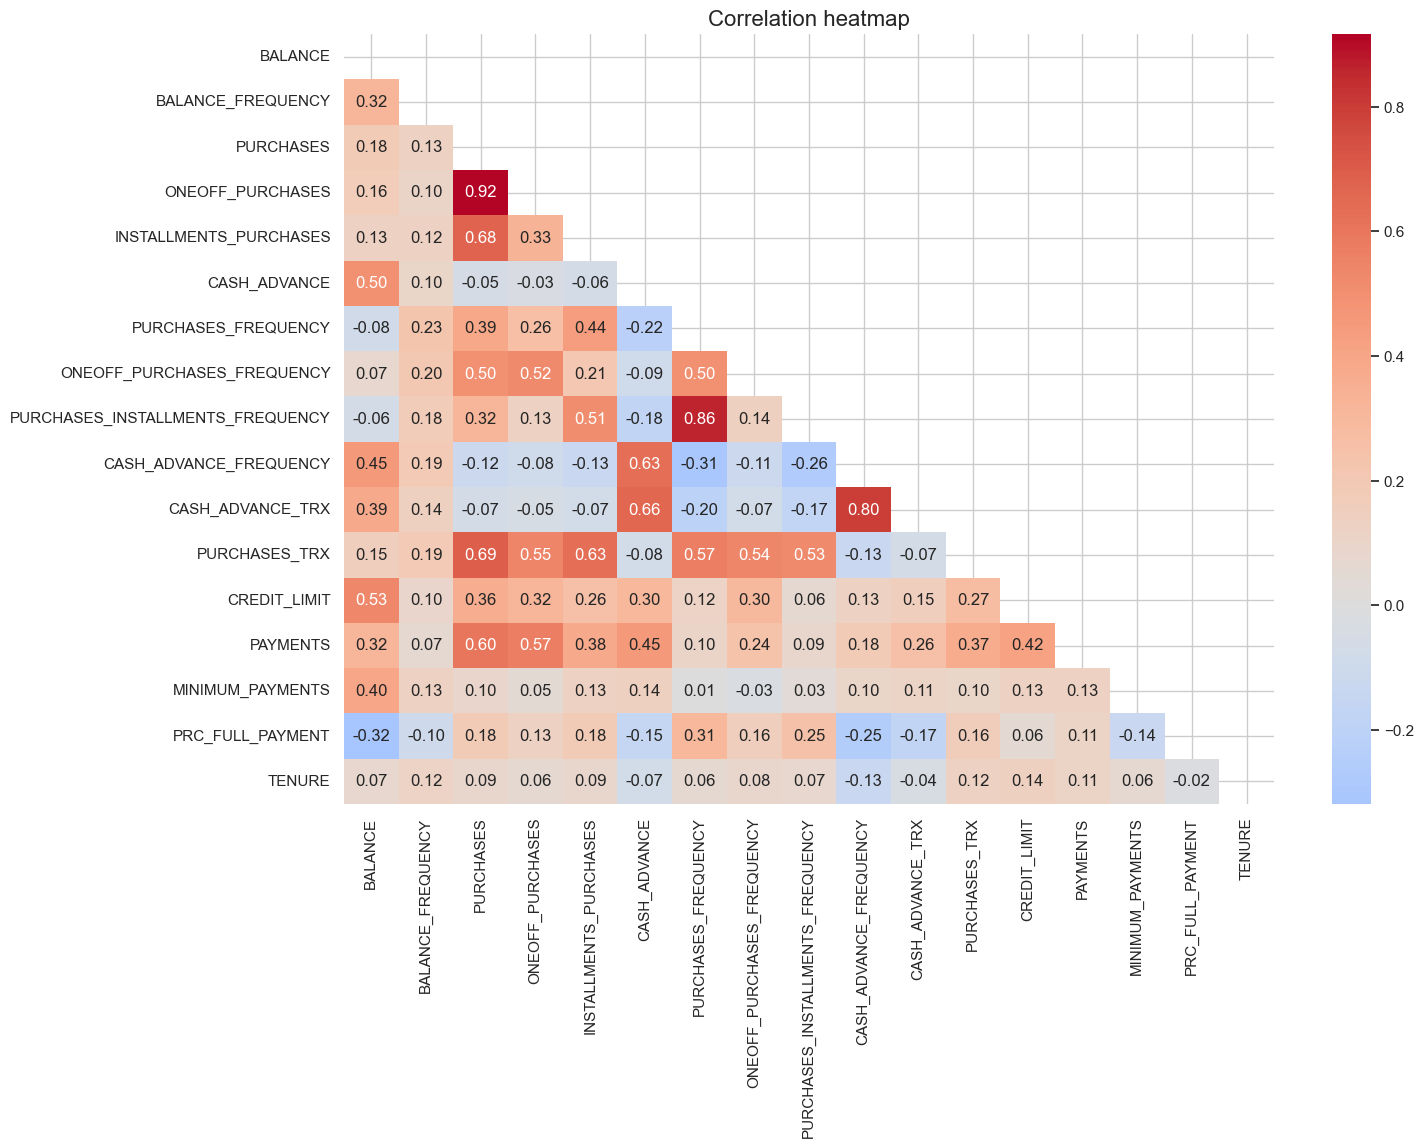

In [ ]:
#dropping CUST_ID as it is non-numeric
corr_matrix = df.drop(columns=['CUST_ID']).corr()

plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask, fmt=".2f", center=0)
plt.title('Correlation heatmap', fontsize=16)
plt.show()


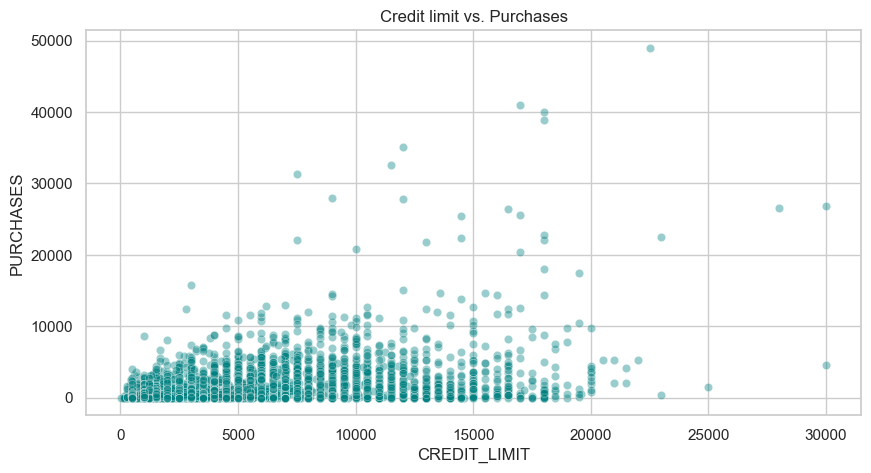

In [13]:
#Scatter plots using significant pairs
#Purchases vs Credit limit (customer action vs potential)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', color='teal', alpha=0.4)
plt.title('Credit limit vs. Purchases')
plt.show()

Even as the CREDIT_LIMIT moves from $0 to 20000, most dots stay very low on the PURCHASES axis. Most customers are under-utilizers (high limit but low risk/spending).

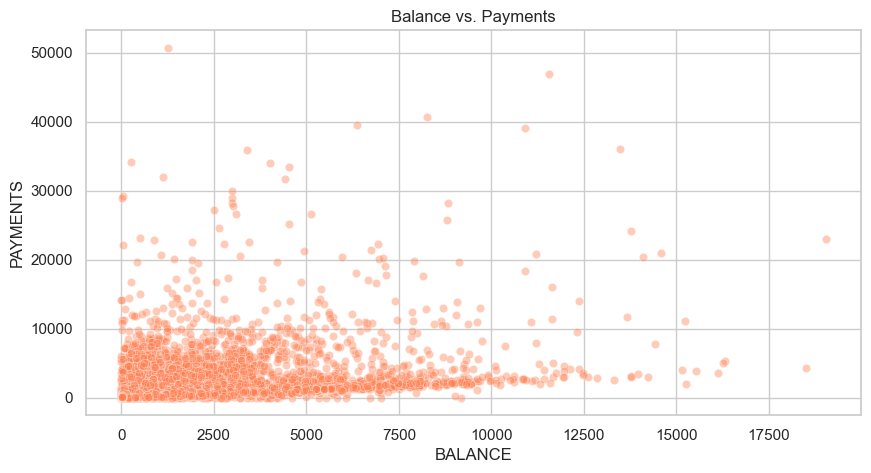

In [14]:
#Balance vs. Payments (Are people paying off debts?)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='BALANCE', y='PAYMENTS', color='coral', alpha=0.4)
plt.title('Balance vs. Payments')
plt.show()


The customers with low PAYMENTS but high BALANCE are the bank's most profitable customers (because of interest), but also the highest risk.

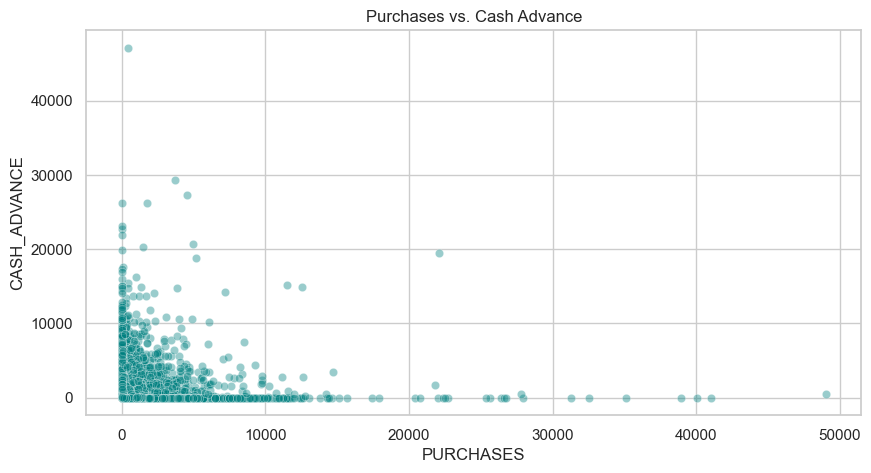

In [15]:
#Purchases vs. Cash advance
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='PURCHASES', y='CASH_ADVANCE', color='teal', alpha=0.4)
plt.title('Purchases vs. Cash Advance')
plt.show()


Many of the customers who use CASH_ADVANCE often have low or 0 purchases.

The bivariate analysis reveals a high degree of variance in customer behavior.
The Credit Limit vs. Purchases plot shows that a high credit ceiling does not strongly correlate with high spending, suggesting a large segment of conservative cardholders.
The Balance vs. Payments plot identifies a clear distinction between customers who pay off their balances and those who carry debt.

These groupings in the scatter plots suggest that a K-Means clustering algorithm will be effective in segmenting this population.

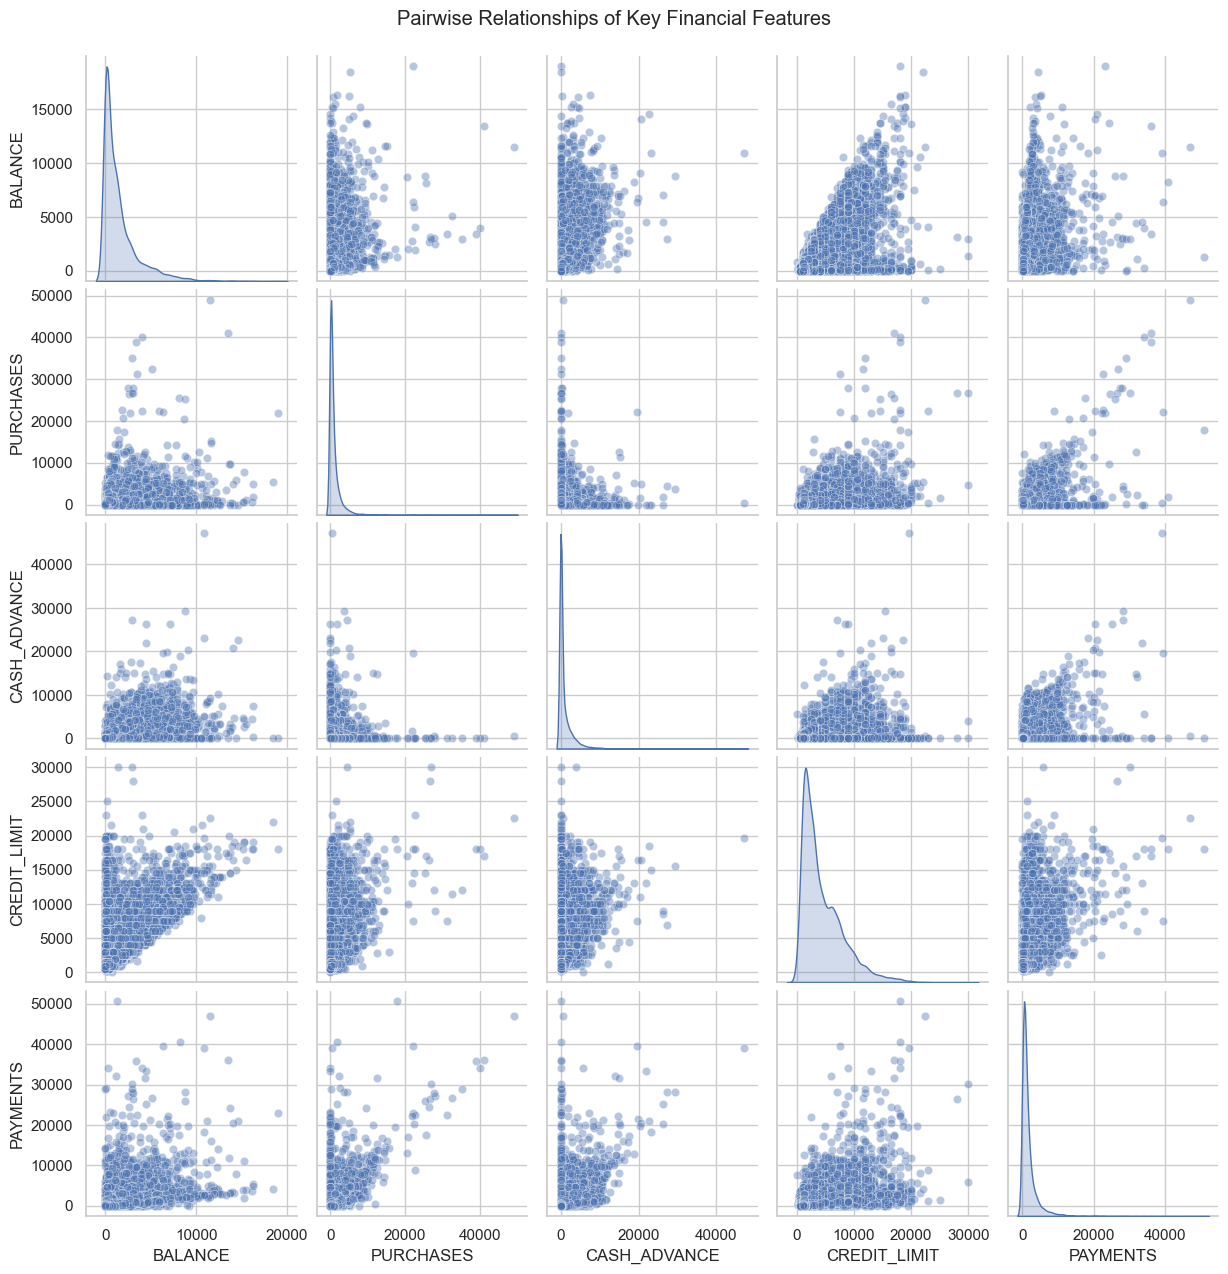

In [16]:
#Pairplot with a subset of key features
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

sns.pairplot(df[key_features], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairwise Relationships of Key Financial Features', y=1.02)
plt.show()

In [17]:
# Creating a simplified category for Full Payment
df['FULL_PAYMENT_CAT'] = pd.cut(df['PRC_FULL_PAYMENT'], bins=[-1, 0.1, 1], labels=['Low/No', 'High'])

# Cross-tabulation
ctab = pd.crosstab(df['TENURE'], df['FULL_PAYMENT_CAT'], normalize='index') * 100
print("Percentage of Payment Categories by Tenure:")
display(ctab.round(2))

Percentage of Payment Categories by Tenure:


FULL_PAYMENT_CAT,Low/No,High
TENURE,,
6,68.63,31.37
7,73.16,26.84
8,71.43,28.57
9,68.57,31.43
10,72.03,27.97
11,76.99,23.01
12,73.66,26.34


Customers with 6-month tenure actually show a higher percentage of full payment compared to the 12-month customers. It suggests newer accounts might be more cautious with debt initially.

# **FEATURE ENGINEERING**

In [18]:
# Spending Behaviors
df['ONEOFF_PURCHASE_RATIO'] = df['ONEOFF_PURCHASES'] / (df['PURCHASES'] + 1)
df['INSTALLMENTS_PURCHASE_RATIO'] = df['INSTALLMENTS_PURCHASES'] / (df['PURCHASES'] + 1)

# Average Transaction Values
df['AVG_PURCHASE_TRX'] = df['PURCHASES'] / (df['PURCHASES_TRX'] + 1)
df['AVG_CASH_ADVANCE_TRX'] = df['CASH_ADVANCE'] / (df['CASH_ADVANCE_TRX'] + 1)

# Payment Behavior
df['MIN_PAYMENT_RATIO'] = df['PAYMENTS'] / (df['MINIMUM_PAYMENTS'] + 1)

# **PREPROCESSING**

In [19]:
#drop CUST_ID and temporary columns
df_model= df.drop(columns=['CUST_ID','FULL_PAYMENT_CAT','PURCHASES'])


In [20]:
df_model

,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,ONEOFF_PURCHASE_RATIO,INSTALLMENTS_PURCHASE_RATIO,AVG_PURCHASE_TRX,AVG_CASH_ADVANCE_TRX,MIN_PAYMENT_RATIO
0,40.900749,0.818182,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,...,1000.0,201.802084,139.509787,0.000000,12,0.000000,0.989627,31.800000,0.000000,1.436214
1,3202.467416,0.909091,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,...,7000.0,4103.032597,1072.340217,0.222222,12,0.000000,0.000000,0.000000,1288.589097,3.822677
2,2495.148862,1.000000,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,...,7500.0,622.066742,627.284787,0.000000,12,0.998708,0.000000,59.474615,0.000000,0.990103
3,1666.670542,0.636364,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,...,7500.0,0.000000,312.343947,0.000000,12,0.999333,0.000000,749.500000,102.894008,0.000000
4,817.714335,1.000000,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,...,1200.0,678.334763,244.791237,0.000000,12,0.941176,0.000000,8.000000,0.000000,2.759800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,...,1000.0,325.594462,48.886365,0.500000,6,0.000000,0.996577,41.588571,0.000000,6.526723
8946,19.183215,1.000000,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,...,1000.0,275.861322,312.343947,0.000000,6,0.000000,0.996678,42.857143,0.000000,0.880379
8947,23.398673,0.833333,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,...,1000.0,81.270775,82.418369,0.250000,6,0.000000,0.993122,24.066667,0.000000,0.974255
8948,13.457564,0.833333,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,...,500.0,52.549959,55.755628,0.250000,6,0.000000,0.000000,0.000000,12.186259,0.925899


In [21]:
#log transformation to handle heavy right-skew
df_log= np.log1p(df_model)

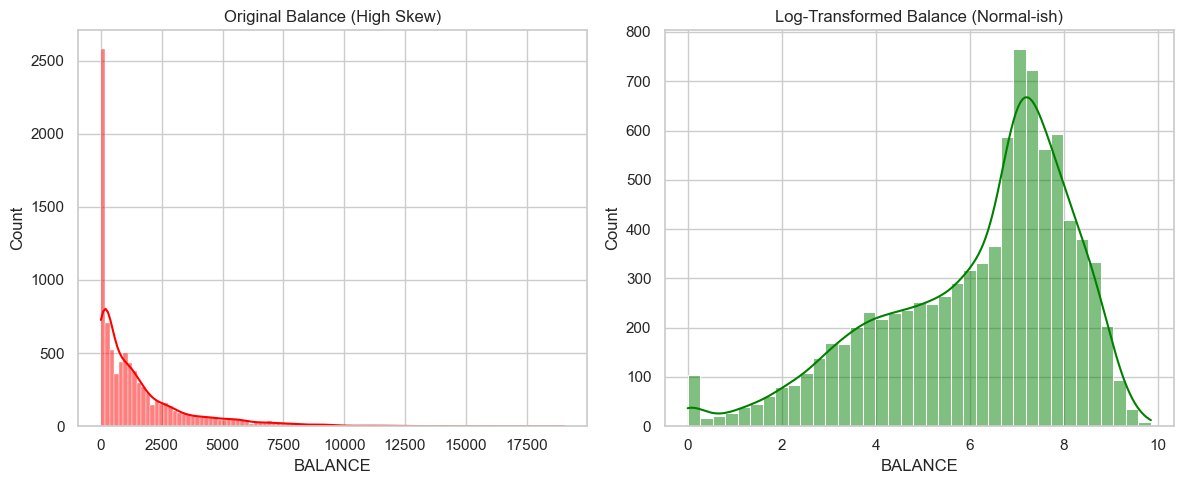

Original Skew: 2.39
Log-Transformed Skew: -0.86


In [22]:
# Let's compare the 'BALANCE' column specifically
plt.figure(figsize=(12, 5))

# Before Log (Original)
plt.subplot(1, 2, 1)
sns.histplot(df_model['BALANCE'], kde=True, color='red')
plt.title('Original Balance (High Skew)')

# After Log Transformation
plt.subplot(1, 2, 2)
sns.histplot(df_log['BALANCE'], kde=True, color='green')
plt.title('Log-Transformed Balance (Normal-ish)')

plt.tight_layout()
plt.show()

# Print skewness values
print(f"Original Skew: {df_model['BALANCE'].skew():.2f}")
print(f"Log-Transformed Skew: {df_log['BALANCE'].skew():.2f}")

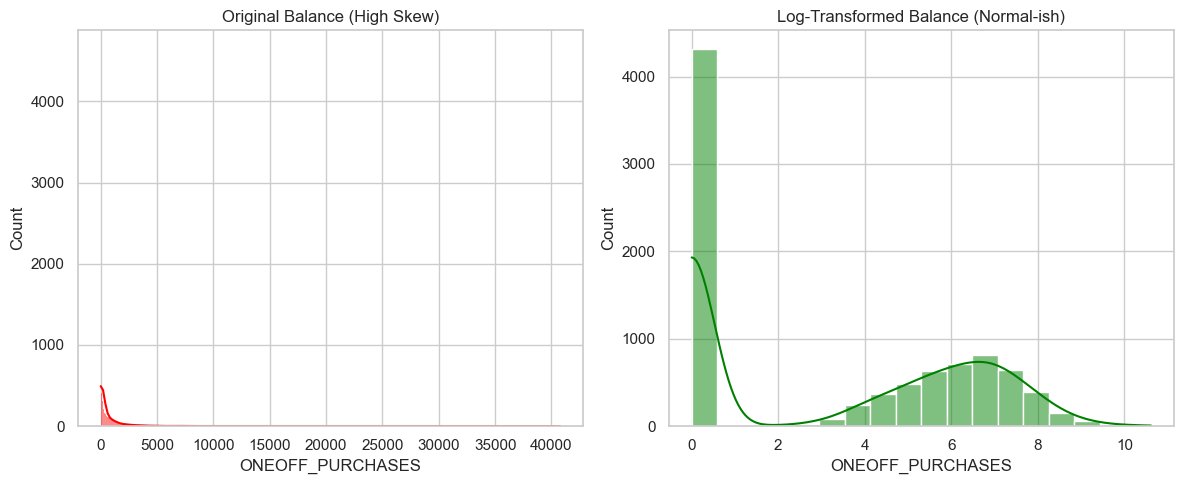

Original Skew: 10.05
Log-Transformed Skew: 0.19


In [23]:
plt.figure(figsize=(12, 5))

# Before Log (Original)
plt.subplot(1, 2, 1)
sns.histplot(df_model['ONEOFF_PURCHASES'], kde=True, color='red')
plt.title('Original Balance (High Skew)')

# After Log Transformation
plt.subplot(1, 2, 2)
sns.histplot(df_log['ONEOFF_PURCHASES'], kde=True, color='green')
plt.title('Log-Transformed Balance (Normal-ish)')

plt.tight_layout()
plt.show()

# Print skewness values
print(f"Original Skew: {df_model['ONEOFF_PURCHASES'].skew():.2f}")
print(f"Log-Transformed Skew: {df_log['ONEOFF_PURCHASES'].skew():.2f}")

In [24]:
#data standardization
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

# **Finding Optimal Clusters (Elbow Method & Silhouette Score)**
We use the Elbow Method to find the "bend" in WCSS and validate it with the Silhouette Score.

### Elbow Method 

In [29]:
k_range = range(2, 11)
wcss = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

k=2: Inertia = 140812.12
k=3: Inertia = 119921.64
k=4: Inertia = 104272.13
k=5: Inertia = 93593.51
k=6: Inertia = 87781.67
k=7: Inertia = 83640.19
k=8: Inertia = 78432.61
k=9: Inertia = 75390.48
k=10: Inertia = 72463.83


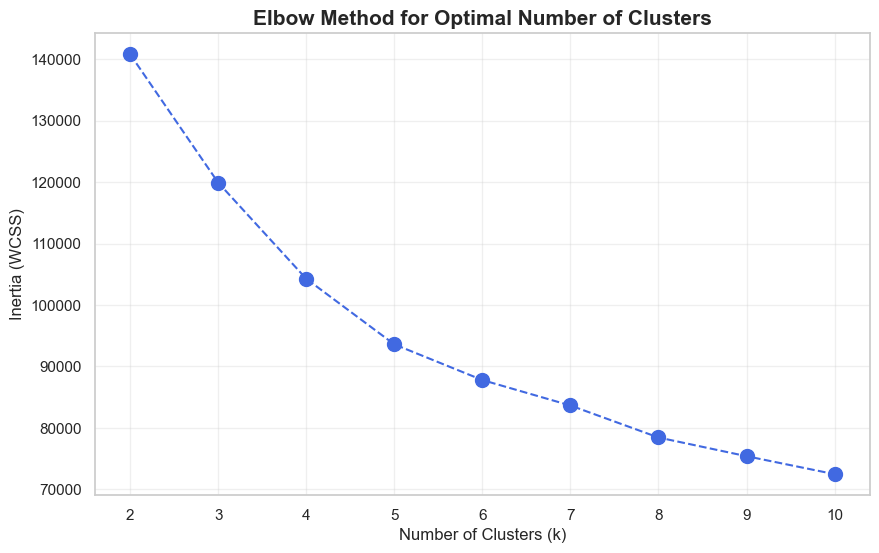

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'o-', markersize=10, linestyle='--', color='royalblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)',fontsize=12)
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

### Silhouette Score

In [ ]:
silhouette_scores = []

for k in k_range:
    # Create and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(df_scaled , cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

k=2: Silhouette Score = 0.249
k=3: Silhouette Score = 0.233
k=4: Silhouette Score = 0.244
k=5: Silhouette Score = 0.246
k=6: Silhouette Score = 0.243
k=7: Silhouette Score = 0.227
k=8: Silhouette Score = 0.224
k=9: Silhouette Score = 0.220
k=10: Silhouette Score = 0.178


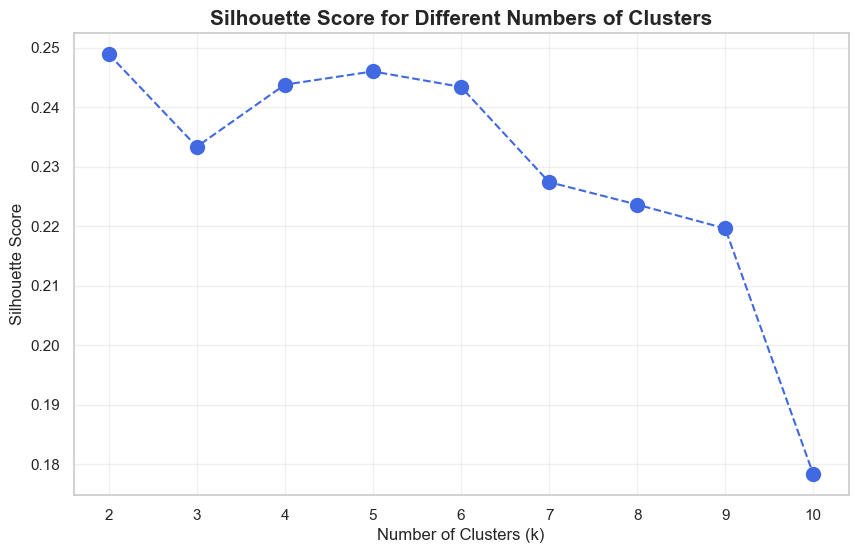

In [32]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores,'o-', markersize=10, linestyle='--', color='royalblue')
plt.xlabel('Number of Clusters (k)',fontsize=12)
plt.ylabel('Silhouette Score',fontsize=12)
plt.title('Silhouette Score for Different Numbers of Clusters', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

##### From the silhouette scores we arrived as k=5 to provide enough variety to ditinguish between "Installment Users" and "Cash Advance Users" without making the segments too small to be usefull 

In [33]:
# Apply K-Means
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(df_scaled)
df_log['Cluster'] = clusters

In [34]:
df_log

,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,ONEOFF_PURCHASE_RATIO,INSTALLMENTS_PURCHASE_RATIO,AVG_PURCHASE_TRX,AVG_CASH_ADVANCE_TRX,MIN_PAYMENT_RATIO,Cluster
0,3.735304,0.597837,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,...,5.312231,4.945277,0.000000,2.564949,0.000000,0.687947,3.490429,0.000000,0.890445,1
1,8.071989,0.646627,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,...,8.319725,6.978531,0.200671,2.564949,0.000000,0.000000,0.000000,7.162079,1.573329,3
2,7.822504,0.693147,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,...,6.434654,6.442994,0.000000,2.564949,0.692501,0.000000,4.102224,0.000000,0.688186,4
3,7.419183,0.492477,7.313220,0.000000,5.331694,0.080042,0.080042,0.000000,0.080042,0.693147,...,0.000000,5.747301,0.000000,2.564949,0.692814,0.000000,6.620740,4.643371,0.000000,0
4,6.707735,0.693147,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,...,6.521114,5.504483,0.000000,2.564949,0.663294,0.000000,2.197225,0.000000,1.324366,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,3.384170,0.693147,0.000000,5.677165,0.000000,0.693147,0.000000,0.606136,0.000000,0.000000,...,5.788719,3.909748,0.405465,1.945910,0.000000,0.691434,3.751586,0.000000,2.018460,1
8946,3.004851,0.693147,0.000000,5.707110,0.000000,0.693147,0.000000,0.606136,0.000000,0.000000,...,5.623517,5.747301,0.000000,1.945910,0.000000,0.691485,3.780938,0.000000,0.631473,1
8947,3.194529,0.606136,0.000000,4.979489,0.000000,0.606136,0.000000,0.510826,0.000000,0.000000,...,4.410016,4.423869,0.223144,1.945910,0.000000,0.689702,3.221539,0.000000,0.680191,1
8948,2.671218,0.606136,0.000000,0.000000,3.625907,0.000000,0.000000,0.000000,0.154151,1.098612,...,3.980615,4.038755,0.223144,1.945910,0.000000,0.000000,0.000000,2.579175,0.655393,3


In [35]:
# Cluster distribution
counts = pd.Series(clusters).value_counts()
print(counts)

4    2505
1    2242
3    2081
2    1219
0     903
Name: count, dtype: int64


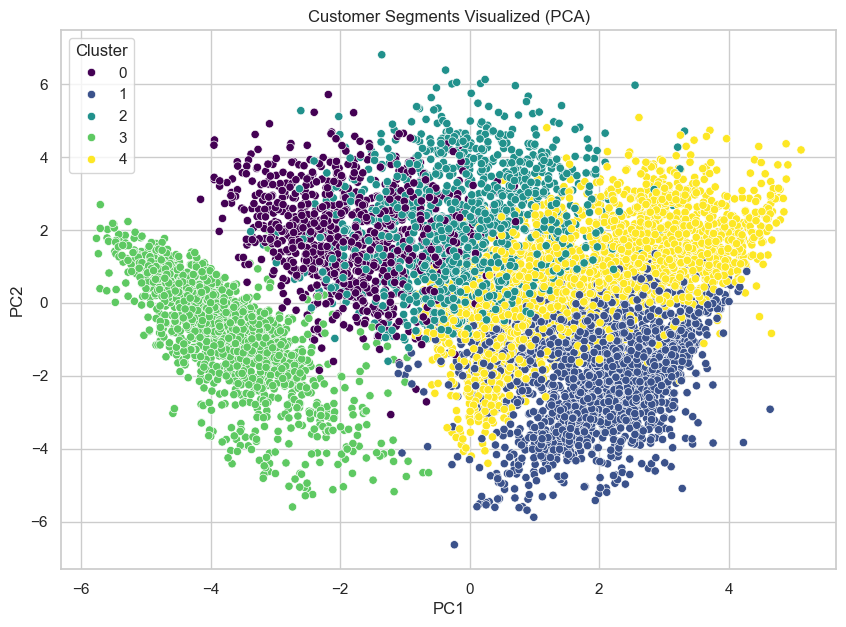

In [36]:
# PCA for Visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis')
plt.title('Customer Segments Visualized (PCA)')
plt.show()

# **Cluster Interpretation & Profiling**
After performing feature engineering and optimizing the model to $k=5$ (based on Silhouette Score and PCA visualization), we have identified five distinct customer segments.

## 1. Segment Summary Table
| Cluster |Business Persona |Key Behavioral Profile |Financial Strategy|
|-----------|---------------|--------------------|------------------|
|0 |Balanced Users |Moderate activity across all ratios; the "average" card user.| Standard loyalty rewards and engagement.|
|1 |The Planners |High `INSTALLMENTS_PURCHASE_RATIO`; prefers monthly payments.| Focus on "Buy Now, Pay Later" (BNPL) offers.|
|2 |High-Risk Revolvers |High `MIN_PAYMENT_RATIO`; pays very little relative to balance.| Monitor for credit risk; offer debt consolidation.|
|3 |The Whales |High `ONEOFF_PURCHASE_RATIO` and `AVG_PURCHASE_TRX`.| Premium perks, higher limits, and luxury rewards.|
|4 |Cash-Reliant Users |High `AVG_CASH_ADVANCE_TRX`; uses card for liquid cash.| High-interest revenue segment; offer personal loans.|

## 2. Detailed Persona Definitions
**Cluster 0**: ***Balanced Users*** These customers represent the core "middle-of-the-road" user. They don't show extreme spikes in spending or debt, making them a stable but low-margin segment for the bank.

**Cluster 1**: ***The Installment Planners*** This group uses credit as a budgeting tool. They prefer structured payments over large one-time hits to their balance. They are generally low-risk and highly predictable.

**Cluster 2**: ***Minimum Payers (The Revolvers***) This is the most critical segment for risk management. They carry high balances and only pay the minimum required. While they generate significant interest income, they are the most susceptible to economic shifts.

**Cluster 3**: ***Luxury/Big Ticket Shoppers*** Identified by their high average transaction value. They don't use the card frequently for small items; instead, they save it for major purchases like electronics, furniture, or travel.

**Cluster 4**: ***Cash-Advance Dependent*** This group treats the credit card like an ATM. Because cash advances often carry higher interest rates and immediate fees, this segment is very profitable but may indicate a lack of traditional liquidity.

### 3. Final Model Statistics
- Optimal K : 5 
- Silhouette Score: ~ 0.246 (Local Peak)
- Feature Drivers: `ONEOFF_PURCHASE_RATIO`, `INSTALLMENTS_PURCHASE_RATIO`, `AVG_PURCHASE_TRX`, `AVG_CASH_ADVANCE_TRX`, `MIN_PAYMENT_RATIO`.

# ****Additional Information****
**Project done by TS ACADEMY NOVARA cohorts GROUP 17**

### **Group Members Information**


| | NAME | EMAIL | GITHUB REPOSITORY |
| :--- | :--- | :--- | :--- |
| 1 | Ilevbare Benjamin Joseph | benjoevybenjamin@gmail.com | https://github.com/Benjoevy |
| 2 | Olorunnishola Taiwo | olorunnisholato7@gmail.com | https://github.com/Te-ne |
| 3 | Bertrand Rosesharon Oluoma | bertsharon14@gmail.com | https://github.com/Ro-nnie12 |
| 4 | Dan Godwin Uduak | nagodwindan@gmail.com | https://github.com/nagodwindan-sys/Godwin |
| 5 | Okanga Chukwuma Jeffrey | jeffokanga@gmail.com | https://github.com/jeph29 |
| 6 | Timothy Orungbemi Anuoluwapo | orungbemitimothy@gmail.com | https://github.com/Timothy-info |
| 7 | Faith Festus Esenam | faithita15@gmail.com | https://github.com/Faithy-15 |
| 8 | Adedokun Joshua Adedamola | Adedokunjoshua35@gmail.com | https://github.com/ADEDAMOLA-20 |
| 9 | Okorigwe Udonna Michael | anthonyokorigwe@gmail.com | https://github.com/Okorigwe123 |
| 10 | Oluwaseun Shoniran | seun.shoniran16@gmail.com | https://github.com/NirvanaShelly |